In [10]:
import pandas as pd
import random

# Step 1 : Months of the Year
months = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]
 
# Step 2 : Realistic Temperature Ranges (°C)
temperature_ranges = {
    "January": (10, 16),
    "February": (14, 20),
    "March": (20, 28),
    "April": (28, 36),
    "May": (35, 44),
    "June": (34, 42),
    "July": (28, 34),
    "August": (27, 33),
    "September": (28, 35),
    "October": (24, 32),
    "November": (18, 26),
    "December": (12, 18)
}

# For same output every time (optional)
random.seed(42)

# Step 3 : Generate Temperature Data
temperatures = []

for month in months:
    temp = round(random.uniform(
        temperature_ranges[month][0],
        temperature_ranges[month][1]
    ), 1)

    temperatures.append(temp)


# Step 4 : Store Data (Dictionary)
temperature_data = {
    "Month": months,
    "Average_Temperature_C": temperatures
}


# Step 5 : Create DataFrame
df = pd.DataFrame(temperature_data)

# Step 6 : Save CSV File 
df.to_csv("average_monthly_temperature.csv", index=False)

print("CSV File Generated Successfully!")
print(df)

CSV File Generated Successfully!
        Month  Average_Temperature_C
0     January                   13.8
1    February                   14.2
2       March                   22.2
3       April                   29.8
4         May                   41.6
5        June                   39.4
6        July                   33.4
7      August                   27.5
8   September                   31.0
9     October                   24.2
10   November                   19.7
11   December                   15.0


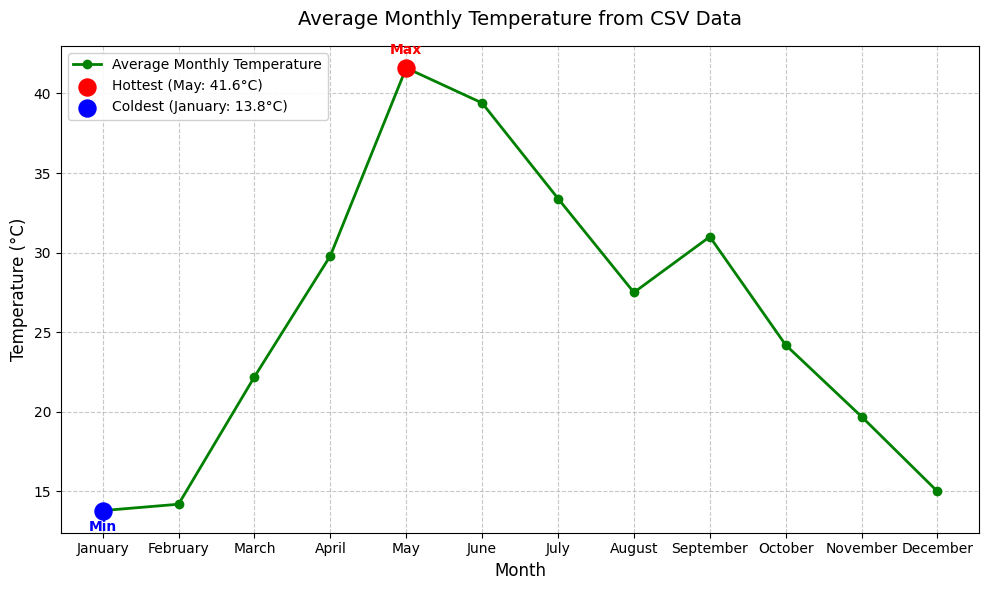

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
# Load Data from CSV
def load_data_from_csv(file_path):

    # Read CSV file
    df = pd.read_csv(file_path)

    # Column names from generated CSV
    months = df['Month']
    temperatures = df['Average_Temperature_C']

    return months, temperatures

# Visualization Function
def visualize_temperatures(months, temperatures):

    # Find hottest and coldest
    max_temp = temperatures.max()
    min_temp = temperatures.min()

    max_index = temperatures.idxmax()
    min_index = temperatures.idxmin()

    max_month = months[max_index]
    min_month = months[min_index]

    plt.figure(figsize=(10,6))

    # Line Plot
    plt.plot(
        months,
        temperatures,
        marker='o',
        linestyle='-',
        linewidth=2,
        color='green',
        label='Average Monthly Temperature'
    )

    # Highlight hottest
    plt.scatter(
        max_month,
        max_temp,
        color='red',
        s=150,
        zorder=5,
        label=f'Hottest ({max_month}: {max_temp}°C)'
    )

    plt.annotate(
        'Max',
        (max_month, max_temp),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        color='red',
        fontweight='bold'
    )

    # Highlight coldest
    plt.scatter(
        min_month,
        min_temp,
        color='blue',
        s=150,
        zorder=5,
        label=f'Coldest ({min_month}: {min_temp}°C)'
    )

    plt.annotate(
        'Min',
        (min_month, min_temp),
        textcoords="offset points",
        xytext=(0,-15),
        ha='center',
        color='blue',
        fontweight='bold'
    )

    # Graph Formatting
    plt.title(
        'Average Monthly Temperature from CSV Data',
        fontsize=14,
        pad=15
    )

    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Temperature (°C)', fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.7)

    plt.legend(loc='upper left', framealpha=0.9)

    plt.tight_layout()

    plt.show()


if __name__ == "__main__":

    # Use Generated CSV File Name
    csv_filename = 'average_monthly_temperature.csv'

    months_data, temps_data = load_data_from_csv(csv_filename)

    visualize_temperatures(months_data, temps_data)